In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("oil_geopolitics_dataset_2010_2026.csv")
print(df.head())

         date  brent_price  wti_price  dxy_index        vix  gpr_index  \
0  2010-02-17    76.269997  77.330002  80.379997  21.719999  80.725357   
1  2010-02-18    77.779999  79.059998  80.400002  20.629999  80.725357   
2  2010-02-19    78.190002  79.809998  80.639999  20.020000  80.725357   
3  2010-02-22    78.610001  80.160004  80.510002  19.940001  80.725357   
4  2010-02-23    77.250000  78.860001  80.849998  21.370001  80.725357   

   brent_return  wti_return  brent_lag_1  brent_lag_3  ...  wti_lag_7  \
0      0.007796    0.004155    75.680000    73.050003  ...  71.190002   
1      0.019798    0.022372    76.269997    72.900002  ...  71.889999   
2      0.005271    0.009486    77.779999    75.680000  ...  73.750000   
3      0.005372    0.004385    78.190002    76.269997  ...  74.519997   
4     -0.017301   -0.016218    78.610001    77.779999  ...  75.279999   

   brent_volatility_7d  brent_volatility_30d  wti_volatility_7d  \
0             0.014461              0.019679     

In [3]:
df.isnull().sum()

date                    0
brent_price             0
wti_price               0
dxy_index               0
vix                     0
gpr_index               0
brent_return            0
wti_return              0
brent_lag_1             0
brent_lag_3             0
brent_lag_7             0
wti_lag_1               0
wti_lag_3               0
wti_lag_7               0
brent_volatility_7d     0
brent_volatility_30d    0
wti_volatility_7d       0
wti_volatility_30d      0
brent_wti_spread        0
event_type              0
event_description       0
event_severity          0
event_flag              0
dtype: int64

In [3]:
x = df[["wti_price",
"dxy_index",
"vix",
"gpr_index",
"brent_lag_1",
"brent_lag_3",
"brent_lag_7",
"wti_lag_1",
"wti_lag_3",
"wti_lag_7",
"brent_volatility_7d",
"brent_volatility_30d",
"wti_volatility_7d",
"wti_volatility_30d",
"brent_wti_spread",
"event_severity",
"event_flag"]]
y = df["brent_price"]
print(x.head())
print(y.head())

   wti_price  dxy_index        vix  gpr_index  brent_lag_1  brent_lag_3  \
0  77.330002  80.379997  21.719999  80.725357    75.680000    73.050003   
1  79.059998  80.400002  20.629999  80.725357    76.269997    72.900002   
2  79.809998  80.639999  20.020000  80.725357    77.779999    75.680000   
3  80.160004  80.510002  19.940001  80.725357    78.190002    76.269997   
4  78.860001  80.849998  21.370001  80.725357    78.610001    77.779999   

   brent_lag_7  wti_lag_1  wti_lag_3  wti_lag_7  brent_volatility_7d  \
0    69.589996  77.010002  75.279999  71.190002             0.014461   
1    70.110001  77.330002  74.129997  71.889999             0.014387   
2    72.129997  79.059998  77.010002  73.750000             0.013342   
3    72.540001  79.809998  77.330002  74.519997             0.013366   
4    73.050003  80.160004  79.059998  75.279999             0.017334   

   brent_volatility_30d  wti_volatility_7d  wti_volatility_30d  \
0              0.019679           0.016977        

In [5]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

In [6]:
from xgboost import XGBRegressor
model = XGBRegressor()
model.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [7]:
predict = model.predict(x_test)
print(predict,"\n")
print(y_test)
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predict)
print(mse)

[ 59.01443   48.848316  48.26586  122.579834  66.385574  55.4537
  93.66564  110.06978  101.907616  47.06267   83.2288    76.34695
  58.993687  96.27753   27.102608  40.424885  85.52416  110.07076
  74.702194  76.042015  94.2912    72.205864  42.956062 106.1247
  87.78734   77.88737   75.508125  55.37863   80.78784   40.688995
  81.68572   74.50925   57.87102   75.858215  55.353718 109.344025
  44.060555  46.592724  65.37291   58.255695  84.43041   48.90052
  63.302334  67.29118   64.54889   71.20589  122.09923   63.0189
  78.90061   41.231125  31.434227  97.56692   58.316074 111.3705
  47.156857  51.59914   83.012054  94.080605 111.12412   68.51765
  72.42672   55.339176 109.50767   86.27738   47.871334 119.02213
  76.39482   69.333115  80.897125  80.68506   64.89385   78.56693
  79.13733   51.954105  98.787     83.603546 108.20417   63.0152
 111.90256   81.86284   77.52821   48.808437 108.31417   69.51383
 115.608734 105.3191    57.09596  108.75254   62.829445  25.075447
  64.856346 

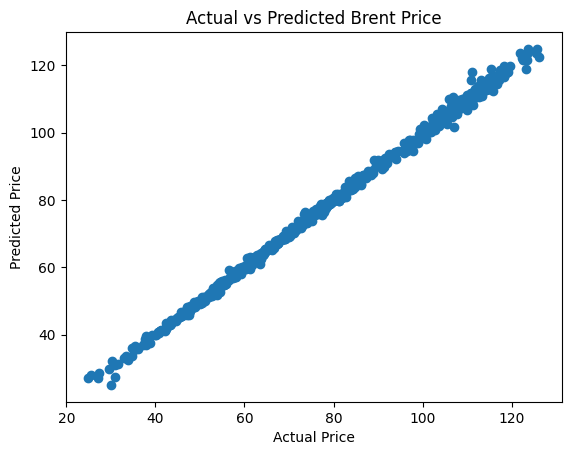

In [8]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predict)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Brent Price")
plt.show()